## 1. Setup & Bagian A: Membaca Citra dan Konversi Warna
OpenCV secara default membaca gambar dalam format matriks BGR, yang akan membuat warna terlihat terbalik (seperti kebiruan) jika langsung divisualisasikan. Kita harus mengonversinya ke RGB.

--- Statistik Citra 1 ---
Ukuran (Shape): (735, 1257, 3)
Tipe Data: uint8
Min Pixel: 0 | Max Pixel: 255


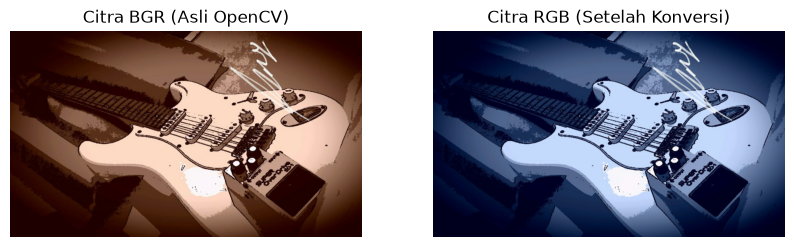

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def show_img(title, img, cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


img1 = cv.imread("image1.jpg")
img2 = cv.imread("image2.jpg")


img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)


print("--- Statistik Citra 1 ---")
print("Ukuran (Shape):", img1_rgb.shape)
print("Tipe Data:", img1_rgb.dtype)
print("Min Pixel:", np.min(img1_rgb), "| Max Pixel:", np.max(img1_rgb))


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); show_img("Citra BGR (Asli OpenCV)", img1)
plt.subplot(1, 2, 2); show_img("Citra RGB (Setelah Konversi)", img1_rgb)
plt.show()

In [8]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Berjalan di environment lokal. Melewati proses mount Google Drive.")

Berjalan di environment lokal. Melewati proses mount Google Drive.


# 2. Bagian B: Resize Citra
Untuk menggabungkan dua matriks gambar, dimensinya harus identik secara absolut.

In [10]:
target_size = (600, 400)

img1_resize = cv.resize(img1_rgb, target_size)
img2_resize = cv.resize(img2_rgb, target_size)

print("Ukuran img1 sebelum:", img1_rgb.shape, " | sesudah:", img1_resize.shape)
print("Ukuran img2 sebelum:", img2_rgb.shape, " | sesudah:", img2_resize.shape)

Ukuran img1 sebelum: (735, 1257, 3)  | sesudah: (400, 600, 3)
Ukuran img2 sebelum: (736, 1308, 3)  | sesudah: (400, 600, 3)


# 3. Bagian C: Image BlendingDi sini kita menerapkan komposisi gambar menggunakan persamaan

 $I_{blend} = \alpha I_1 + \beta I_2 + \gamma$.

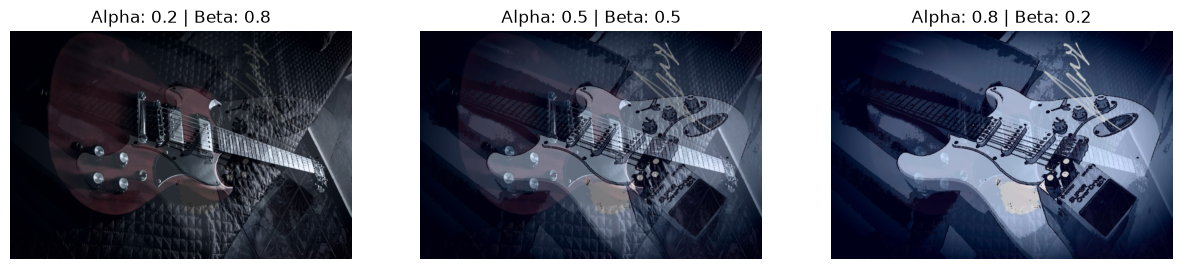

In [11]:
weights = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]

plt.figure(figsize=(15, 5))
for i, (alpha, beta) in enumerate(weights):
    # Menggunakan cv.addWeighted untuk blending
    img_blend = cv.addWeighted(img1_resize, alpha, img2_resize, beta, 0)
    plt.subplot(1, 3, i+1)
    show_img(f"Alpha: {alpha} | Beta: {beta}", img_blend)
plt.show()

# 4. Bagian D: Image Negative
Membalikkan nilai pixel dengan mengurangkan nilai maksimum (255).

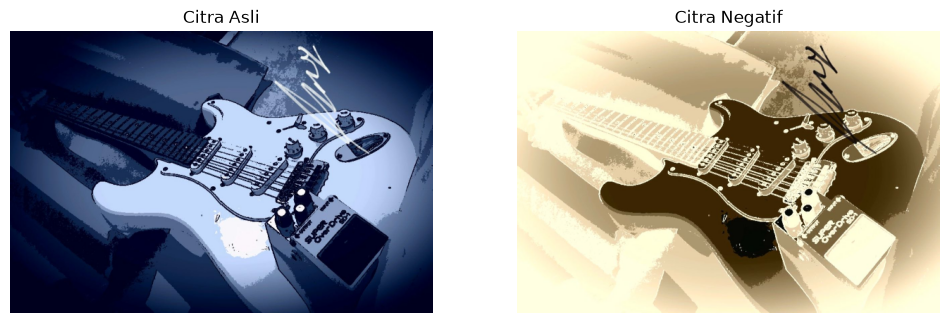

C:\Users\ahfur\AppData\Local\Temp\ipykernel_15044\674838079.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img1_resize.ravel(), 256, [0, 256], color='blue')
C:\Users\ahfur\AppData\Local\Temp\ipykernel_15044\674838079.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_negative.ravel(), 256, [0, 256], color='orange')


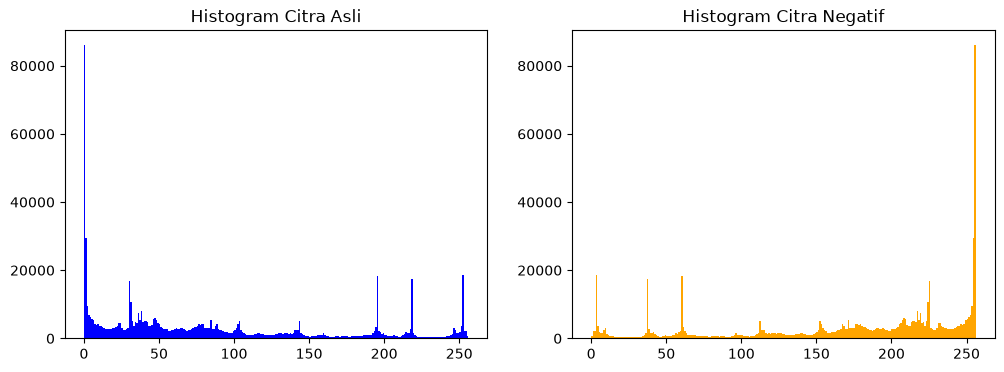

In [12]:
img_negative = 255 - img1_resize

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); show_img("Citra Asli", img1_resize)
plt.subplot(1, 2, 2); show_img("Citra Negatif", img_negative)
plt.show()

# Menampilkan Histogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(img1_resize.ravel(), 256, [0, 256], color='blue')
plt.title("Histogram Citra Asli")

plt.subplot(1, 2, 2)
plt.hist(img_negative.ravel(), 256, [0, 256], color='orange')
plt.title("Histogram Citra Negatif")
plt.show()

# 5. Bagian E: Transformasi Logaritmik
Konsep ini sangat berguna untuk mengangkat detail pada shadows tanpa melakukan overexposing pada area yang sudah terang, menggunakan fungsi:
# $$s = c \log(1+r)$$

Min/Max Asli: 0 / 255
Min/Max Log Transform: 0 / 255


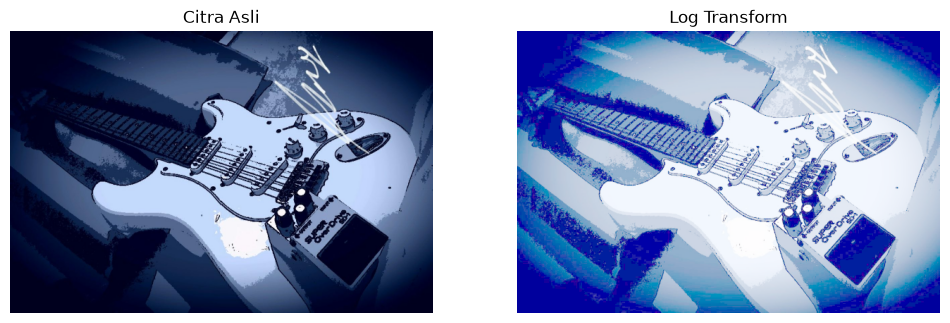

In [13]:
# Menghindari error pembulatan dengan konversi ke float64
img1_float = img1_resize.astype(np.float64)

# Menghitung konstanta 'c'
c = 255 / np.log10(1 + np.max(img1_float))
img_log = c * np.log10(img1_float + 1)

# Konversi kembali ke integer 8-bit
img_log = np.array(img_log, dtype=np.uint8)

print("Min/Max Asli:", np.min(img1_resize), "/", np.max(img1_resize))
print("Min/Max Log Transform:", np.min(img_log), "/", np.max(img_log))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); show_img("Citra Asli", img1_resize)
plt.subplot(1, 2, 2); show_img("Log Transform", img_log)
plt.show()

# 6. Bagian F: Transformasi Gamma
Mengontrol midtones (kecerahan keseluruhan) melalui eksponen kurva. Nilai pixel harus dinormalisasi ke rentang 0 - 1 terlebih dahulu.

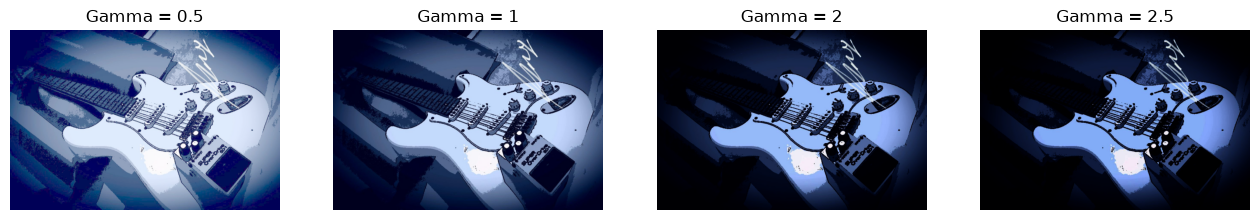

In [15]:
gammas = [0.5, 1, 2, 2.5]
img_normalized = img1_resize / 255.0

plt.figure(figsize=(16, 4))
for i, gamma in enumerate(gammas):
    # s = r^gamma
    img_gamma = img_normalized ** gamma

    # Kembalikan ke rentang 0-255 untuk divisualisasikan dengan benar
    img_gamma_uint8 = np.clip(img_gamma * 255, 0, 255).astype(np.uint8)

    plt.subplot(1, 4, i+1)
    show_img(f"Gamma = {gamma}", img_gamma_uint8)
plt.show()